## Random Forest

### Import Libraries

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

### Load Dataset

In [9]:
df = pd.read_csv("cleaned_customer_financial_behaviour.csv")

### Select Features and Target

In [10]:
X = df.drop("default_12m", axis=1)
y = df["default_12m"]

### Split Dataset

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train Random Foreset

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Make Prediction

In [13]:
y_pred = rf_model.predict(X_test)

### Perform Evaluation

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9231851851851852
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0


C:\Users\DHARVIN\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### Confusion Matrix

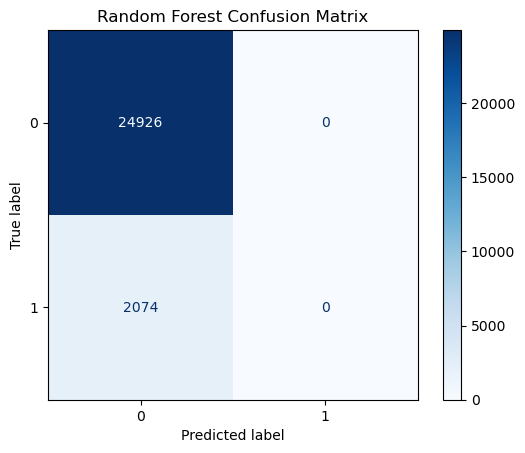

In [15]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix")
plt.show()

### Features Importance

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

                              Feature  Importance
3                       annual_income    0.114411
4                      monthly_income    0.113949
11  revolving_utilization_origination    0.112191
6                       interest_rate    0.111692
8                                 emi    0.110588
10           credit_score_origination    0.106945
9                                 dti    0.085033
0                                 age    0.079274
12               credit_inquiries_12m    0.043323
7                           loan_term    0.026493
14                       vintage_year    0.025785
5                         loan_amount    0.023738
2                   employment_status    0.019008
1                              gender    0.015679
13              deterioration_pattern    0.011892


### Plot Importene

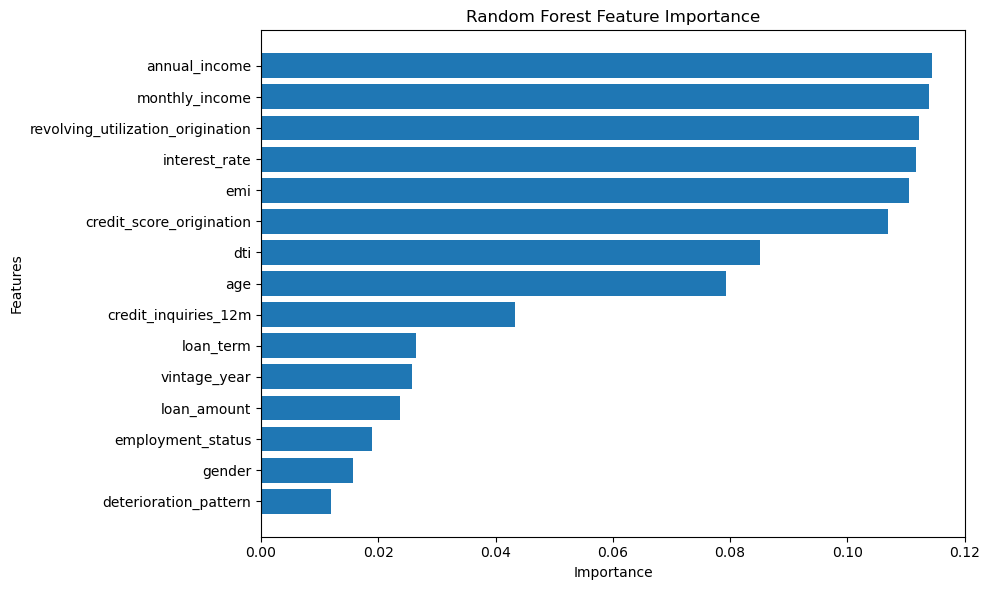

In [17]:
plt.figure(figsize=(10,6))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()